## Figure 11: Measured current front speed vs the speed expected from scaling for different mixing regimes

In [1]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress
from matplotlib.lines import Line2D

# Use given style and color maps
from colors import mixing_c_map, type_marker_map

plt.style.use("james2026lock.mplstyle")

# constants
rho_water = 998.2  # Freshwater density [kg/m³]
rho_bent = 2277  # Wetted bentonite density [kg/m³]
h0 = 0.25  # initial water height [m]
l0 = 0.27  # mixing chamber length [m]
v0 = h0 * l0
a_thresh = 0.06  # m/s² for example (below this velocity taken as roughly constant)

# load experiment table
metadata = pd.read_csv("data/metadata.csv")
folder = "/Users/cara/Library/CloudStorage/OneDrive-UBC/PhD/Experiments/2025/Experiment_files/datafiles"

Slope = 0.41398546767350236 +/- 0.013131169637080995
Intercept = 0.0011584906157266692 +/- 0.0019474710426158205
particle slope = 0.39008036875461494 +/- 0.014260018185163459
particle itercept = -0.00024559502328107274 +/- 0.0019181519527720747
R2 = 0.9739680514893115
saline slope = 0.41135858110651635 +/- 0.014260018185163459
saline itercept = 0.004778300177137033 +/- 0.0019181519527720747
R2 = 0.9739680514893115


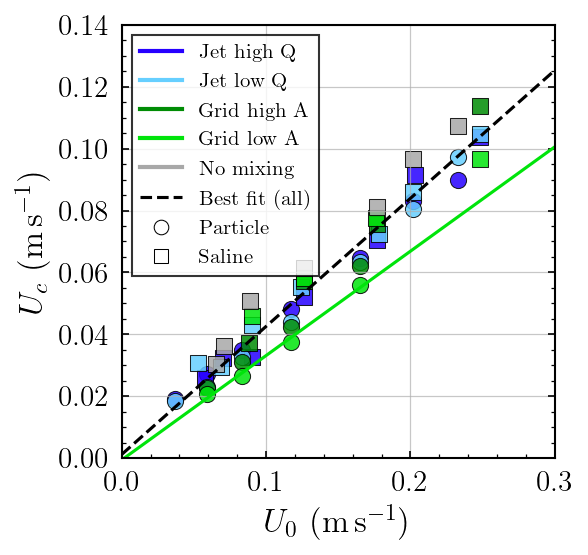

In [2]:
# ============== plot ==============
fig, ax = plt.subplots(
    1,
    1,
    figsize=(4, 4),
)

# --- Scatter plot colored by mixing category ---
# Loop through mixing categories
for mixing_type, color in mixing_c_map.items():
    df_mix = metadata[metadata["mixing"] == mixing_type]

    # Within each mixing category, split by type for markers
    for t, marker in type_marker_map.items():
        df_sub = df_mix[df_mix["type"] == t]

        if len(df_sub) == 0:
            continue

        ax.scatter(
            df_sub["u_0"],
            df_sub["u_c"],
            color=color,
            marker=marker,
            edgecolor="k",
            linewidth=0.5,
            s=60,
            alpha=0.85,
        )

        if mixing_type == "grid low A" and t == "part":
            # Best-fit line panel 1
            x = df_sub["u_0"].values
            y = df_sub["u_c"].values
            m, b = np.polyfit(x, y, 1)
            x_fit = np.linspace(0, 1, 200)
            y_fit = m * x_fit + b
            ax.plot(x_fit, y_fit, "-", color=color, linewidth=1.5)


# Best-fit line panel 1
x = metadata["u_0"].values
y = metadata["u_c"].values
res = linregress(x, y)
m = res.slope
b = res.intercept
m_err = res.stderr
b_err = res.intercept_stderr
R2 = res.rvalue**2
x_fit = np.linspace(0, 1, 200)
y_fit = m * x_fit + b
ax.plot(x_fit, y_fit, "--", color="black", linewidth=1.5, label="Best fit")
print("Slope =", m, "+/-", m_err)
print("Intercept =", b, "+/-", b_err)

x = metadata[metadata["type"] == "part"]["u_0"].values
y = metadata[metadata["type"] == "part"]["u_c"].values
res = linregress(x, y)
m = res.slope
b = res.intercept
m_err = res.stderr
b_err = res.intercept_stderr
R2 = res.rvalue**2
print("particle slope =", m, "+/-", m_err)
print("particle itercept =", b, "+/-", b_err)
print("R2 =", R2)

x = metadata[metadata["type"] == "saline"]["u_0"].values
y = metadata[metadata["type"] == "saline"]["u_c"].values
m, b = np.polyfit(x, y, 1)
print("saline slope =", m, "+/-", m_err)
print("saline itercept =", b, "+/-", b_err)
print("R2 =", R2)

ax.set_ylim([0, 0.14])
ax.set_xlim([0, 0.30])
ax.set_xlabel("$U_0$ (m\\,s$^{-1}$)")
ax.set_ylabel("$U_c$ (m\\,s$^{-1}$)")
ax.set_box_aspect(1)

label_map = {
    "stagnation high Q": "Jet high Q",
    "stagnation low Q": "Jet low Q",
    "grid high A": "Grid high A",
    "grid low A": "Grid low A",
    "none": "No mixing",
}

legend_elements = [
    *[
        Line2D(
            [0],
            [0],
            color=color,
            linewidth=2,
            label=label_map.get(mixing_type, mixing_type),
        )
        for mixing_type, color in mixing_c_map.items()
    ],
    Line2D([0], [0], color="k", linestyle="--", linewidth=1.5, label="Best fit (all)"),
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        label="Particle",
        markerfacecolor="white",
        markeredgecolor="k",
        markeredgewidth=0.5,
        markersize=7,
    ),
    Line2D(
        [0],
        [0],
        marker="s",
        color="w",
        label="Saline",
        markerfacecolor="white",
        markeredgecolor="k",
        markeredgewidth=0.5,
        markersize=7,
    ),
]
ax.legend(handles=legend_elements, loc="upper left", fontsize=10)

plt.tight_layout()
plt.show()

/var/folders/v4/_48l42jj6nnf6xdxm2f8xp7c0000gp/T/ipykernel_68446/3201889599.py:54: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(
/var/folders/v4/_48l42jj6nnf6xdxm2f8xp7c0000gp/T/ipykernel_68446/3201889599.py:54: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


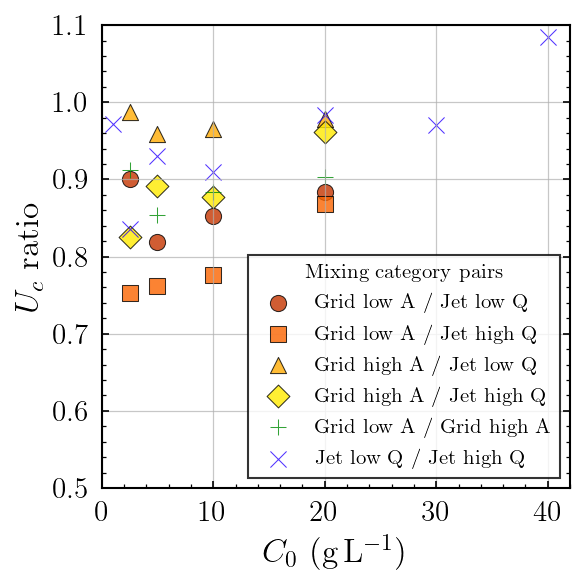

In [3]:
# Define the pairs you want to compare
pairs = [
    ("grid low A", "stagnation low Q"),
    ("grid low A", "stagnation high Q"),
    ("grid high A", "stagnation low Q"),
    ("grid high A", "stagnation high Q"),
    ("grid low A", "grid high A"),
    ("stagnation low Q", "stagnation high Q"),
]

labels = [
    ("Grid low A / Jet low Q"),
    ("Grid low A / Jet high Q"),
    ("Grid high A / Jet low Q"),
    ("Grid high A / Jet high Q"),
    ("Grid low A / Grid high A"),
    ("Jet low Q / Jet high Q"),
]

# Define markers for each pair
markers = [
    "o",
    "s",
    "^",
    "D",
    "+",
    "x",
]  # circle, square, triangle, diamond, plus, cross

colours = [
    "#C53400",
    "#FB6400",
    "#FFAB03",
    "#FFEA00",
    "#008c05",
    "#2600FF",
]  # circle, square, triangle, diamond, plus, cross


fig, ax = plt.subplots(1, 1, figsize=(4, 4))

for (mix_x, mix_y), marker, color in zip(pairs, markers, colours):
    # Select only particle experiments (if needed)
    df_x = metadata[(metadata["mixing"] == mix_x) & (metadata["type"] == "part")]
    df_y = metadata[(metadata["mixing"] == mix_y) & (metadata["type"] == "part")]

    # Match experiments by C_0
    common_C0 = np.intersect1d(df_x["C0"].values, df_y["C0"].values)
    df_x_matched = df_x[df_x["C0"].isin(common_C0)].sort_values("C0")
    df_y_matched = df_y[df_y["C0"].isin(common_C0)].sort_values("C0")

    u_c_ratio = np.array(df_x_matched["u_c"]) / np.array(df_y_matched["u_c"])

    ax.scatter(
        df_x_matched["C0"],
        u_c_ratio,
        marker=marker,
        color=color,
        edgecolor="k",
        linewidth=0.5,
        s=60,
        alpha=0.8,
        label=f"{mix_x} / {mix_y}",
    )


ax.set_ylim([0.5, 1.1])
ax.set_xlim([0, 42])
ax.set_xlabel("$C_0$ (g\\,L$^{-1})$")
ax.set_ylabel("$U_c$ ratio ")

ax.legend(
    labels=labels,
    loc="lower right",
    title="Mixing category pairs",
    fontsize="medium",
    title_fontsize="medium",
)

plt.tight_layout()
plt.show()

min nm ratio: 0.4592793672316385, max nm ratio: 0.5702490112359552


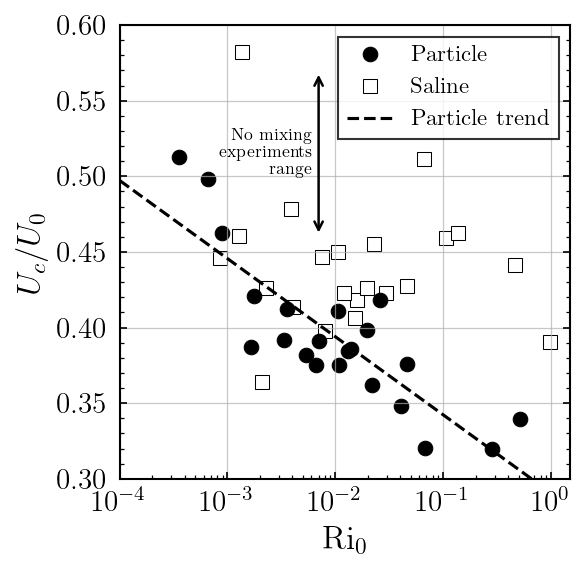

In [4]:
# ============== plot ==============
fig, ax = plt.subplots(
    1,
    1,
    figsize=(4, 3.9),
)

# --- Scatter plot colored by mixing category ---
# Loop through mixing categories
zord = 1
for t, marker in type_marker_map.items():
    df_sub = metadata[metadata["type"] == t]

    c = "white" if t == "saline" else "black"

    # if t == "saline":
    #     continue
    ax.semilogx(
        df_sub["Ri_0"],
        df_sub["u_c"] / (df_sub["u_0"]),
        color=c,
        marker=marker,
        markerfacecolor=c,
        markeredgecolor="k",
        markeredgewidth=0.5,
        markersize=7,
        linestyle="",
        alpha=1,
        zorder=zord,
    )

    if t == "saline":
        nm_ratio = (
            df_sub[df_sub.mixing == "none"]["u_c"].values
            / df_sub[df_sub.mixing == "none"]["u_0"].values
        )
        print(f"min nm ratio: {np.min(nm_ratio)}, max nm ratio: {np.max(nm_ratio)}")

    if t == "part":
        # Best-fit line
        x = np.log10(df_sub["Ri_0"].values)
        y = df_sub["u_c"].values / df_sub["u_0"].values
        m, b = np.polyfit(x, y, 1)
        x_fit = np.linspace(-4, 1, 200)
        y_fit = m * x_fit + b
        plt.plot(10**x_fit, y_fit, "k--")

    zord -= 1


# Best-fit line panel 1
ax.set_xlabel("Ri$_0$ ")
ax.set_ylabel("$U_c/U_0$ ")

# Best-fit line panel 1
ax.set_xlim(0.0001, 1.5)
ax.set_ylim(0.3, 0.6)

legend_elements = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        label="Particle",
        markerfacecolor="black",
        markeredgecolor="k",
        markeredgewidth=0.5,
        markersize=7,
    ),
    Line2D(
        [0],
        [0],
        marker="s",
        color="w",
        label="Saline",
        markerfacecolor="white",
        markeredgecolor="k",
        markeredgewidth=0.5,
        markersize=7,
    ),
    Line2D([0], [0], color="k", linestyle="--", label="Particle trend"),
]
ax.legend(handles=legend_elements, loc="upper right", fontsize=11)

ax.annotate(
    "",
    xy=(0.7e-2, 0.57),
    xytext=(0.7e-2, 0.46),
    arrowprops=dict(arrowstyle="<->", color="k", lw=1.2),
)

ax.text(
    6e-3, 0.515, "No mixing\nexperiments\nrange", fontsize=8, va="center", ha="right"
)

plt.tight_layout()
plt.show()

all: slope=0.414±0.013, intercept=0.001±0.002, R²=0.953
part: slope=0.390±0.014, intercept=-0.000±0.002, R²=0.974
saline: slope=0.411±0.015, intercept=0.005±0.002, R²=0.967
NM ratio: 0.459–0.570


/var/folders/v4/_48l42jj6nnf6xdxm2f8xp7c0000gp/T/ipykernel_68446/2048569902.py:112: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax[1].scatter(
/var/folders/v4/_48l42jj6nnf6xdxm2f8xp7c0000gp/T/ipykernel_68446/2048569902.py:112: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax[1].scatter(


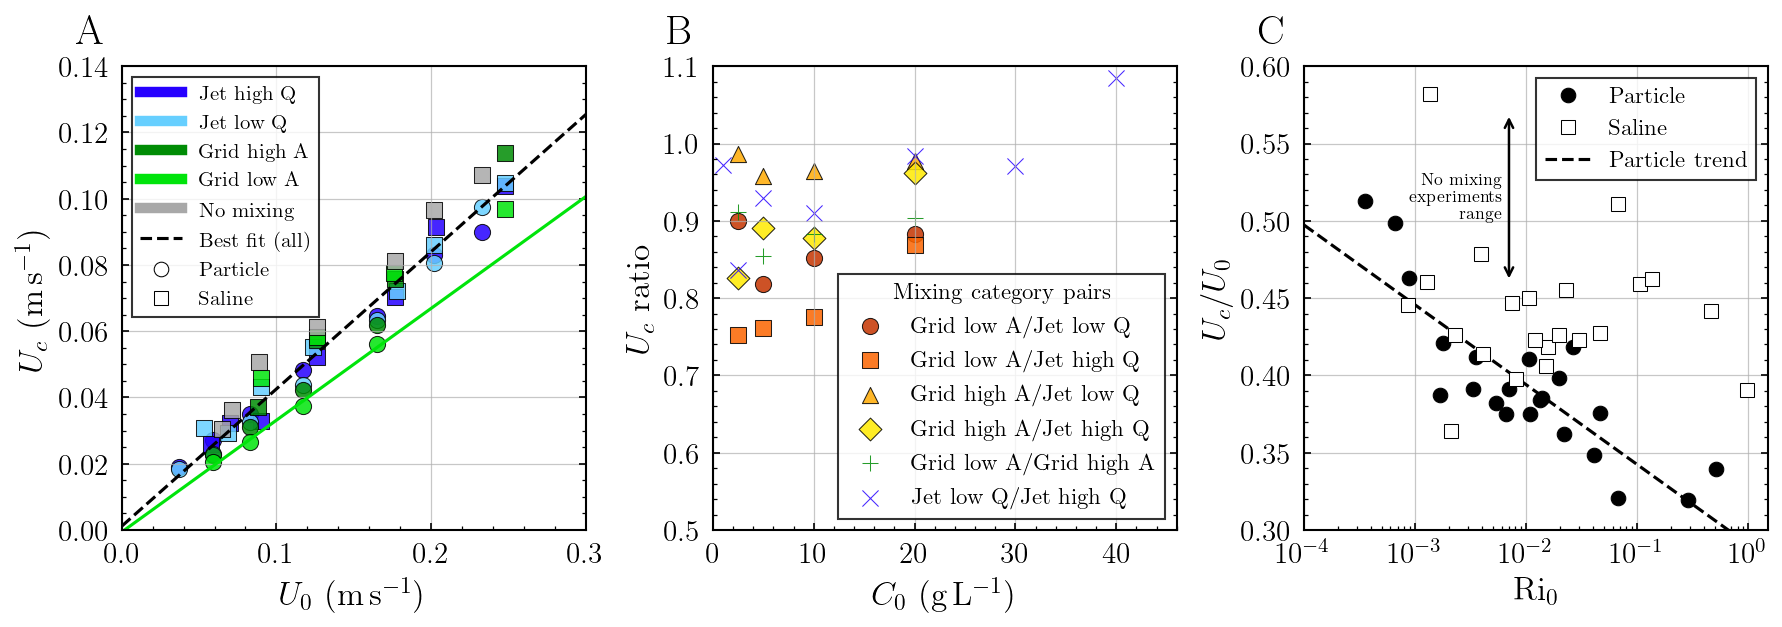

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4.3))

scatter_kw = dict(edgecolor="k", linewidth=0.5, s=60, alpha=0.85)

# ============== Panel A ==============
for mixing_type, color in mixing_c_map.items():
    for t, marker in type_marker_map.items():
        df_sub = metadata[(metadata["mixing"] == mixing_type) & (metadata["type"] == t)]
        if df_sub.empty:
            continue
        ax[0].scatter(
            df_sub["u_0"], df_sub["u_c"], color=color, marker=marker, **scatter_kw
        )
        if mixing_type == "grid low A" and t == "part":
            m, b = np.polyfit(df_sub["u_0"], df_sub["u_c"], 1)
            x_fit = np.linspace(0, 1, 200)
            ax[0].plot(x_fit, m * x_fit + b, "-", color=color, linewidth=1.5)

for subset in ["all", "part", "saline"]:
    df = metadata if subset == "all" else metadata[metadata["type"] == subset]
    res = linregress(df["u_0"], df["u_c"])
    print(
        f"{subset}: slope={res.slope:.3f}±{res.stderr:.3f}, "
        f"intercept={res.intercept:.3f}±{res.intercept_stderr:.3f}, R²={res.rvalue**2:.3f}"
    )

x_fit = np.linspace(0, 1, 200)
res = linregress(metadata["u_0"], metadata["u_c"])
ax[0].plot(x_fit, res.slope * x_fit + res.intercept, "k--", linewidth=1.5)
ax[0].set(
    xlim=[0, 0.30],
    ylim=[0, 0.14],
    xlabel="$U_0$ (m\\,s$^{-1}$)",
    ylabel="$U_c$ (m\\,s$^{-1}$)",
)

label_map = {
    "stagnation high Q": "Jet high Q",
    "stagnation low Q": "Jet low Q",
    "grid high A": "Grid high A",
    "grid low A": "Grid low A",
    "none": "No mixing",
}

legend_elements = [
    *[
        Line2D(
            [0],
            [0],
            color=color,
            linewidth=5,
            label=label_map.get(mixing_type, mixing_type),
        )
        for mixing_type, color in mixing_c_map.items()
    ],
    Line2D([0], [0], color="k", linestyle="--", linewidth=1.5, label="Best fit (all)"),
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        label="Particle",
        markerfacecolor="white",
        markeredgecolor="k",
        markeredgewidth=0.5,
        markersize=7,
    ),
    Line2D(
        [0],
        [0],
        marker="s",
        color="w",
        label="Saline",
        markerfacecolor="white",
        markeredgecolor="k",
        markeredgewidth=0.5,
        markersize=7,
    ),
]
ax[0].legend(handles=legend_elements, loc="upper left", fontsize=10)


# ============== Panel B ==============
pairs = [
    ("grid low A", "stagnation low Q"),
    ("grid low A", "stagnation high Q"),
    ("grid high A", "stagnation low Q"),
    ("grid high A", "stagnation high Q"),
    ("grid low A", "grid high A"),
    ("stagnation low Q", "stagnation high Q"),
]
pair_labels = [
    "Grid low A/Jet low Q",
    "Grid low A/Jet high Q",
    "Grid high A/Jet low Q",
    "Grid high A/Jet high Q",
    "Grid low A/Grid high A",
    "Jet low Q/Jet high Q",
]
pair_markers = ["o", "s", "^", "D", "+", "x"]
pair_colours = ["#C53400", "#FB6400", "#FFAB03", "#FFEA00", "#008c05", "#2600FF"]

for (mix_x, mix_y), marker, color, lbl in zip(
    pairs, pair_markers, pair_colours, pair_labels
):
    df_x = metadata[(metadata["mixing"] == mix_x) & (metadata["type"] == "part")]
    df_y = metadata[(metadata["mixing"] == mix_y) & (metadata["type"] == "part")]
    common = np.intersect1d(df_x["C0"], df_y["C0"])
    df_x, df_y = df_x[df_x["C0"].isin(common)].sort_values("C0"), df_y[
        df_y["C0"].isin(common)
    ].sort_values("C0")
    ax[1].scatter(
        df_x["C0"],
        df_x["u_c"].values / df_y["u_c"].values,
        marker=marker,
        color=color,
        label=lbl,
        **scatter_kw,
    )

ax[1].set(
    xlim=[0, 46], ylim=[0.5, 1.1], xlabel="$C_0$ (g\\,L$^{-1}$)", ylabel="$U_c$ ratio"
)
ax[1].legend(
    loc="lower right",
    title="Mixing category pairs",
    fontsize=11,
    title_fontsize=11,
)

# ============== Panel C ==============
for t, marker in type_marker_map.items():
    df_sub = metadata[metadata["type"] == t]
    c = "white" if t == "saline" else "black"
    ax[2].semilogx(
        df_sub["Ri_0"],
        df_sub["u_c"] / df_sub["u_0"],
        color=c,
        marker=marker,
        markerfacecolor=c,
        markeredgecolor="k",
        markeredgewidth=0.5,
        markersize=7,
        linestyle="",
    )
    if t == "saline":
        nm = df_sub[df_sub.mixing == "none"]
        print(
            f"NM ratio: {(nm['u_c']/nm['u_0']).min():.3f}–{(nm['u_c']/nm['u_0']).max():.3f}"
        )
    if t == "part":
        x = np.log10(df_sub["Ri_0"].values)
        m, b = np.polyfit(x, df_sub["u_c"].values / df_sub["u_0"].values, 1)
        x_fit = np.linspace(-4, 1, 200)
        ax[2].plot(10**x_fit, m * x_fit + b, "k--")

ax[2].set(xlim=[0.0001, 1.5], ylim=[0.3, 0.6], xlabel="Ri$_0$", ylabel="$U_c/U_0$")
ax[2].legend(
    handles=[
        Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            label="Particle",
            markerfacecolor="black",
            markeredgecolor="k",
            markeredgewidth=0.5,
            markersize=7,
        ),
        Line2D(
            [0],
            [0],
            marker="s",
            color="w",
            label="Saline",
            markerfacecolor="white",
            markeredgecolor="k",
            markeredgewidth=0.5,
            markersize=7,
        ),
        Line2D([0], [0], color="k", linestyle="--", label="Particle trend"),
    ],
    loc="upper right",
    fontsize=11,
)
ax[2].annotate(
    "",
    xy=(0.7e-2, 0.57),
    xytext=(0.7e-2, 0.46),
    arrowprops=dict(arrowstyle="<->", color="k", lw=1.2),
)
ax[2].text(
    6e-3, 0.515, "No mixing\nexperiments\nrange", fontsize=8, va="center", ha="right"
)

# ============== Labels ==============
for axis, label in zip(ax, ["A", "B", "C"]):
    axis.set_box_aspect(1)
    axis.annotate(
        label,
        xy=(-0.1, 1.05),
        xycoords="axes fraction",
        fontsize=20,
        fontweight="bold",
    )

plt.tight_layout()
plt.savefig("figures/figure_11.png", bbox_inches="tight", dpi=300)
plt.show()